In [1]:
import numpy as np
import pandas as pd


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
import statsmodels.api as sm
from statsmodels.stats import diagnostic as diag
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('Salary_Data (2).csv')

In [3]:
df.head()

,YearsExperience,Salary
0,1.1,39.343
1,1.3,46.205
2,1.5,37.731
3,2.0,43.525
4,2.2,39.891


In [14]:
df.tail()

,YearsExperience,Salary
25,9.0,105.582
26,9.5,116.969
27,9.6,112.635
28,10.3,122.391
29,10.5,121.872


# Checking DataTypes

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


# Univariate Analysis

In [16]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.00000
mean,5.313333,76.00300
std,2.837888,27.41443
min,1.100000,37.73100
25%,3.200000,56.72075
50%,4.700000,65.23700
75%,7.700000,100.54475
max,10.500000,122.39100


# Identify & Treatment of OUtlier

<Axes: ylabel='YearsExperience'>

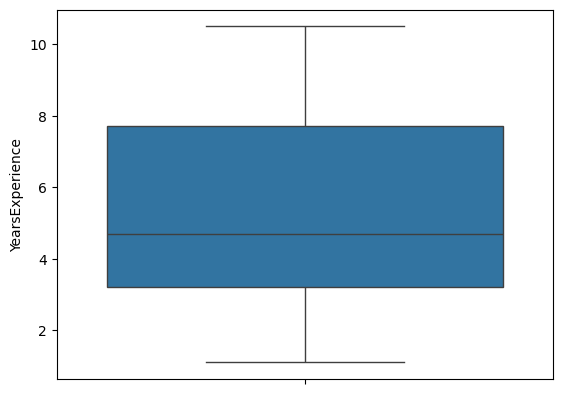

In [18]:
sns.boxplot(y = 'YearsExperience',data=df)


# Missing Value

In [19]:
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

# Data Partition

In [21]:
df.head()

,YearsExperience,Salary
0,1.1,39.343
1,1.3,46.205
2,1.5,37.731
3,2.0,43.525
4,2.2,39.891


In [22]:
x = df[['YearsExperience']]
y = df[['Salary']]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.7,random_state=100)

In [23]:
train = pd.concat([x_train,y_train], axis=1)

In [24]:
train.head()

,YearsExperience,Salary
17,5.3,83.088
22,7.9,101.302
11,4.0,55.794
4,2.2,39.891
29,10.5,121.872


# Correlation

Scatter Plot (Bi-variate Analysis)

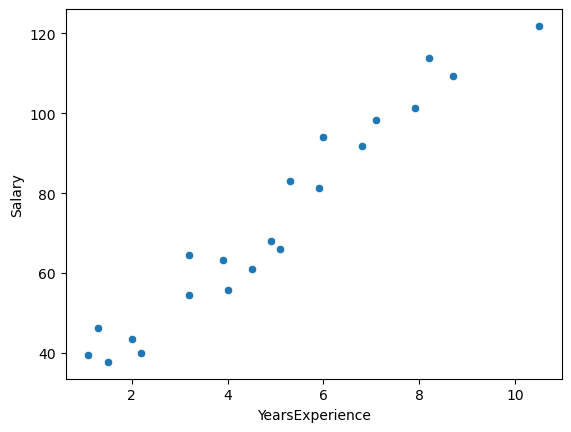

In [25]:
sns.scatterplot(x='YearsExperience', y='Salary',data=train)
plt.show()

Correlation Matrix

In [26]:
train.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.974123
Salary,0.974123,1.000000


<Axes: >

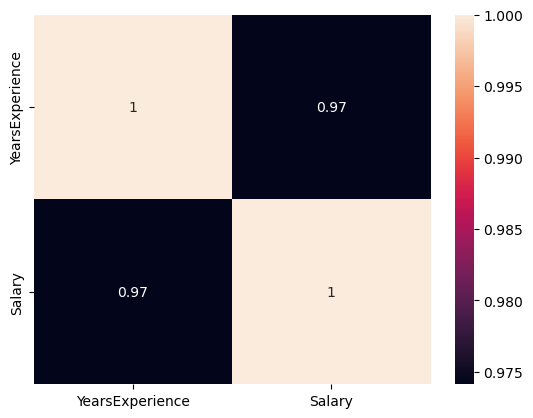

In [27]:
sns.heatmap(train.corr(),annot=True)

# Model Building

In [30]:
import statsmodels.formula.api as smf
model = smf.ols('Salary ~ YearsExperience', data=train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     352.9
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           9.91e-14
Time:                        12:48:23   Log-Likelihood:                -66.742
No. Observations:                  21   AIC:                             137.5
Df Residuals:                      19   BIC:                             139.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          25.2029      2.875      8.765      0.000      19.185      31.221
YearsExperience     9.7312      0.518     18.786      0.000       8.647      10.815
==============================================================================
Omnibus:                        1.843   Durbin-Watson:                   1.749
Prob(Omnibus):                  0.398   Jarque-Bera (JB):                1.106
Skew:                           0.219   Prob(JB):                        0.575
Kurtosis:                       1.964   Cond. No.                         12.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
train['fitted_value'] = model.fittedvalues
train['residual'] = model.resid

train.head()

,YearsExperience,Salary,fitted_value,residual
17,5.3,83.088,76.778268,6.309732
22,7.9,101.302,102.079398,-0.777398
11,4.0,55.794,64.127703,-8.333703
4,2.2,39.891,46.611536,-6.720536
29,10.5,121.872,127.380528,-5.508528


# Homoscedasivity ( Constant Variance )

# Prediction on Test Data (Unseen Data)

In [32]:
test = pd.concat([x_test,y_test],axis=1)
test.head()

,YearsExperience,Salary
9,3.7,57.189
26,9.5,116.969
28,10.3,122.391
13,4.1,57.081
5,2.9,56.642


In [33]:
test['Predicted'] = model.predict(test)
test

,YearsExperience,Salary,Predicted
9,3.7,57.189,61.208342
26,9.5,116.969,117.649324
28,10.3,122.391,125.434287
13,4.1,57.081,65.100824
5,2.9,56.642,53.423379
12,4.0,56.957,64.127703
27,9.6,112.635,118.622445
25,9.0,105.582,112.783722
6,3.0,60.150,54.396499


# TRAIN

In [34]:
from sklearn.metrics import r2_score
r2 = r2_score(train.Salary, train.fitted_value)
print('r2 score for perfect model is : ',np.round(r2,2)*100)

r2 score for perfect model is :  95.0


# TEST

In [35]:
from sklearn.metrics import r2_score
r2 = r2_score(test.Salary, test.Predicted)
print('R2 score for model Performance on Test : ',np.round(r2,2)*100)

R2 score for model Performance on Test :  96.0


# Predictin on Live Data

In [40]:
d1 = {'Customer':pd.Series(['Om','Datta','Prasad']),
        'YearsExperience':pd.Series([6.8,3.0,-6])}
live = pd.DataFrame(d1)
live

,Customer,YearsExperience
0,Om,6.8
1,Datta,3.0
2,Prasad,-6.0


In [41]:
live['future prediction'] = np.round(model.predict(live))
live

,Customer,YearsExperience,future prediction
0,Om,6.8,91.0
1,Datta,3.0,54.0
2,Prasad,-6.0,-33.0
